# Recovering rules from every CommonLII judgment (Track A2)

Goal: extract the legal **rule** from all 3,703 CommonLII reported judgments, and
link each rule to the statute sections its headnote names. The original
`Held:`-marker extractor only fired on 524 of them. This notebook uses a hardened,
structure-aware parser (**Track A2**) that reads the NLR/SLR headnote layout
directly:

```
[registry / case no.] -> [CATCHWORDS: topic - topic - topic. / ... ?] -> [RULE] -> [body start]
```

It is **deterministic and verbatim** (no LLM), and **precision-first**: when the
structure is not clean it **abstains** (those cases fall back to the bounded LLM
track) rather than emit something that is not a rule. The parser was hardened
case-by-case against every failure mode found in the corpus: `?`-terminated
catchwords, `Per JUDGE -` / `Withers, J. -` rule attributions, SLR headers,
section-dash catchwords (`s. 642-Application`), long multi-topic catchword lists,
and body-narrative bleed. A precision guard drops any candidate that is itself a
dash-topic list.

All output is `status=unverified` and lawyer-gated.

## 0. Setup

In [1]:
import json
import re
import random
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "data" / "processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PROCESSED = ROOT / "data" / "processed"
OUT = ROOT / "evaluation" / "runs" / "headnote-recovery-v1"
OUT.mkdir(parents=True, exist_ok=True)

PAL = ["#2F6F5E", "#C08A2D", "#7A8B99", "#8A5510", "#4E6E5D", "#B0663A", "#3E5C6E"]
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})

def barh(labels, values, title, xlabel="count", color=PAL[0]):
    fig, ax = plt.subplots(figsize=(7, 0.5 * len(labels) + 1.2))
    ax.barh(range(len(labels)), values, color=color)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels); ax.invert_yaxis()
    ax.set_xlabel(xlabel); ax.set_title(title, loc="left", fontweight="bold")
    for i, v in enumerate(values):
        ax.text(v, i, f" {v:,}", va="center", fontsize=9)
    plt.tight_layout(); plt.show()

print("repo root:", ROOT)

repo root: d:\projects\Draftly-Project\draftly-research


## 1. Load every CommonLII case

In [2]:
cases = pd.read_json(PROCESSED / "cases.jsonl", lines=True)
cl = cases[cases["source"] == "commonlii"].copy()
TEXT_PATH = dict(zip(cl["case_id"], cl["text_path"]))
CITATION = dict(zip(cl["case_id"], cl["citation"]))
YEAR = dict(zip(cl["case_id"], cl["year"]))
print(f"CommonLII cases: {len(cl):,}  (LKCA {int((cl['court']=='LKCA').sum())}, LKSC {int((cl['court']=='LKSC').sum())})")

def load_text(cid):
    rel = TEXT_PATH.get(cid)
    p = ROOT / rel if rel and not Path(rel).is_absolute() else Path(rel or "")
    return p.read_text(encoding="utf-8", errors="replace") if p.exists() else ""


CommonLII cases: 3,703  (LKCA 3330, LKSC 373)


## 2. The hardened Track A2 parser

In [3]:
# ---------- Track A2 parser (deterministic, verbatim; no LLM) ----------
import re

HEADER = re.compile(r"\(\d{4}\)\s+\d+\s+(?:NLR|Sri\s?LR|S\.?\s?L\.?\s?R\.?|New\s?L\.?\s?R\.?)\s+\d+\s*\([^)]*\)", re.I)
NAV = re.compile(r"(?:Home \| Databases|You are here|Feedback\b|\bHelp\b)")
BODY = re.compile(
    r"(?:THE|T\s?HE)\s+(?:facts?|plaintiffs?|defendants?|appellants?|respondents?|petitioners?|following|action|above)\b"
    r"|(?:THIS|T\s?HIS)\s+(?:action|appeal|application|suit|case)\s+(?:was|is|being)\b"
    r"|\bThe\s+(?:facts?|following)\b"
    r"|A\s?PPEAL\s+(?:from|against|by|is|was|to|and)"
    r"|A\s?PPLICATION\s+(?:for|by|to|was|is|made|under)"
    r"|Cur\.?\s*adv\.?\s*vult"
    r"|I[Nn]\s+this\s+(?:case|action|matter|suit|appeal|application)\b"
    r"|On\s+the\s+trial\b|At\s+the\s+trial\b"
    r"|[A-Z][\w. ]{2,30}?,?\s+for\s+(?:the\s+)?(?:appellant|respondent|plaintiff|defendant|petitioner|added|substituted|intervenient|accused)"
    r"|[A-Z][A-Za-z]+\s*,?\s?[AC]?\.?\s?[CJ]\.\s?[JI]?\.?\s*[—\-]\s")
HELD = re.compile(r"\bHeld\b\s*[:,\-—(]?", re.I)
HAS_LOWER = re.compile(r"[a-z]{3,}")
# topic dash: used ONLY for the rule-content catchword-list guard. Requires a
# space on at least one side of the dash, matching how genuine catchword lists
# are actually typeset in this corpus ("Lease - Assignment - Breach"). Without
# this, the guard false-fires on ordinary no-space hyphenated compounds that
# are common in Sri Lankan legal prose: co-owner(s), judgment-debtor,
# judgment-creditor, Plaintiff-Appellant, Defendant-Respondent, Roman-Dutch,
# Attorney-General -- confirmed as the dominant cause of the
# rule-is-catchword-list bucket (180/182 sampled cases used a no-space
# compound, not a real topic list).
DASH = re.compile(r"[A-Za-z0-9)\"'?](?:[ ][—\-]|[—\-][ ])[\"'(]?[A-Za-z]{2}")
# broadened: catchword-boundary detection only. � = corrupted em-dash from harvest
# encoding (899/3703 files affected), {1,2} covers "--" typeset dashes
DASH_CATCH = re.compile(r"[A-Za-z0-9)\"'?][ ]?[\u2014\-\ufffd]{1,2}[ ]?[\"'(]?[A-Za-z]{2}")
PER_LEAD = re.compile(
    r"^(?:Per\s+|PER\s+)?(?:[A-Z][A-Za-z']+\.?\s*){1,3},?\s*(?:[ACJ]\.\s?){1,3}"
    r"(?:(?:and|&|,)\s+(?:[A-Z][A-Za-z']+\.?\s*){1,3},?\s*(?:[ACJ]\.\s?){1,3})?\s*[-—–:]\s*")
LEAD = [
    re.compile(r"^\s*\[[^\]]*\]\s*"),
    re.compile(r"^\s*\d{3,4}\b\s*"),
    re.compile(r"^\s*\d{4}\b\s*"),
    re.compile(r"^\s*Present\s*:.*?[A-Z]\.?\s?[JA]\.?\s*(?:,?\s*and\s+[^.]*?[JA]\.\s*)?", re.I),
    re.compile(r"^[^-]{0,90}?\bv[\.\s]\s*[A-Z][^-]{0,80}?(?=\s+(?:\d|[A-Z]\.\s?[CRP]\.|[A-Z][a-z]))"),
    re.compile(r"^\s*(?:with\s+)?(?:\d+[,\s]*)?(?:[A-Z]\.\s?){1,3}[A-Za-z][A-Za-z ]*?[, ]\s*[\d,]+\s*(?:\([^)]*\)\s*)?(?:[-—]\s?(?:[A-Z]\.\s?){1,3}[A-Za-z][A-Za-z ]*?[, ]\s*[\d,]+\s*)?(?:/[A-Za-z]+)?\s*[:.]?\s*"),
    re.compile(r"^\s*[\d,]+\s*[-—:/]\s*"),
]
ABBR = {"s", "ss", "sec", "secs", "no", "nos", "rs", "v", "vs", "art", "arts", "cap",
        "ord", "r", "j", "cj", "aj", "c", "a", "i", "e", "g", "viz", "etc", "co", "ltd",
        "mr", "dr", "st", "pp", "p", "ch", "cf", "ex", "re", "hon", "esq", "vol"}


def _clean_catchwords(seg):
    prev = None
    while prev != seg:
        prev = seg
        for pat in LEAD:
            seg = pat.sub("", seg, count=1).strip()
    return re.sub(r"^[^A-Za-z\"']+", "", seg).strip()


def find_catch_end(content):
    """First '.'/'?' that ends the catchword list: follows a dash-run, is not a
    '- ' continuation, and starts a sentence (abbreviation-aware)."""
    for m in re.finditer(r"[.?]", content):
        i = m.start()
        after = content[i + 1:i + 6]
        if re.match(r"\s*[-—–]", after):
            continue
        # allow an immediate closing quote before the required whitespace+capital,
        # e.g. `...possession." Withers, J.` (quote directly abuts the period)
        if not re.match(r"[\"']?\s+(?:[A-Z\"]|Held|HELD)", after):
            continue
        if content[i] == ".":
            pv = re.search(r"([A-Za-z]+|\d+)\s*$", content[:i])
            tok = pv.group(1).lower() if pv else ""
            if tok in ABBR or (tok.isalpha() and len(tok) == 1):
                continue
        before = content[:i]
        if len(DASH_CATCH.findall(before)) >= 2 or DASH_CATCH.search(content[max(0, i - 140):i]):
            return i
    return None


def parse_headnote(text, debug=False):
    """Return {'catchwords','rule'} or None (or (None, reason) when debug)."""
    t = re.sub(r"\s+", " ", text).strip()
    hs = list(HEADER.finditer(t))
    content = t[hs[-1].end():] if hs else t
    navs = list(NAV.finditer(content[:600]))
    if navs:
        content = content[navs[-1].end():]
    content = content[:3800]

    P = find_catch_end(content[:1600])
    if P is None:
        return (None, "no-catch-terminator") if debug else None
    catchwords = _clean_catchwords(content[:P + 1])
    if not (HAS_LOWER.search(catchwords) and DASH_CATCH.search(catchwords)):
        return (None, "catch-not-topic-list") if debug else None
    if len(catchwords) > 800:
        return (None, "catch-too-long") if debug else None

    # strip a leading "Per JUDGE -" attribution before the body search
    after = PER_LEAD.sub("", content[P + 1:].lstrip(" .,-—–")).strip()
    bm = BODY.search(after)
    rule_win = after[: bm.start()] if bm else after[:1300]
    hm = HELD.search(rule_win)
    if hm:
        rule_win = rule_win[hm.start():]
    rule = rule_win.strip(" .;:-—").strip()
    rule = re.split(
        r"\s+(?:A\s?CTION\b|A\s?PPEAL\s+from|A\s?PPLICATION\b|PLAINTIFFS?\b|DEFENDANTS?\b|"
        r"APPELLANTS?\b|RESPONDENTS?\b|PETITIONERS?\b|CASE\s+(?:stated|referred)|PETITION\b|"
        r"T\s?HE\s+facts?\b|Cur\.?\s*adv\.?\s*vult|IN\s+this\s+(?:case|action))", rule)[0].strip()
    rule = re.sub(r"\s+\d{1,4}\s*$", "", rule).strip()
    rule = re.sub(r"\s+[A-Z]\s?HE\s.*$", "", rule).strip()
    if re.match(r"held\b", rule):
        rule = "Held" + rule[4:]
    if len(rule) < 40:
        return (None, "rule-too-short") if debug else None
    if rule.count(" ") < 6:
        return (None, "rule-too-few-words") if debug else None
    if len(DASH.findall(rule)) >= 4:                 # a dash-list is catchwords, not a rule
        return (None, "rule-is-catchword-list") if debug else None
    if len(rule) > 1400:
        rule = rule[:1400].rsplit(".", 1)[0]
    return {"catchwords": catchwords.rstrip(".?") + ".", "rule": rule.rstrip(".") + "."}


In [4]:
# ---------- statute linker (section-centric) ----------
reg_df = pd.read_csv(ROOT / "data" / "legal-sources" / "manifests" / "source-registry.csv")
SECIDX = json.loads((ROOT / "data" / "legal-sources" / "derived" / "statute-section-index.json").read_text(encoding="utf-8"))
SECSET = {k: {str(s["section"]) for s in v} for k, v in SECIDX.items()}

ALIAS = {}
for _, r in reg_df[reg_df["source_type"].isin(["statute", "amendment"])].iterrows():
    ALIAS[str(r["official_title"]).lower()] = r["source_id"]
ALIAS.update({"civil procedure code": "SRC030", "c.p.c.": "SRC030", "cpc": "SRC030",
              "partition ordinance": "SRC024", "prevention of frauds ordinance": "SRC001",
              "registration of documents ordinance": "SRC005", "notaries ordinance": "SRC014",
              "registration of title act": "SRC011"})
STAT_NAMES = sorted(ALIAS, key=len, reverse=True)
SEC_RE = re.compile(r"(?:sections?|ss?\.|sec\.?|8\.)\s*(\d+[A-Za-z]?)", re.I)
NAME_RE = re.compile("|".join(re.escape(n) for n in STAT_NAMES), re.I)


def _nearest_statute(text, pos):
    best, bestd = None, 10**9
    for m in NAME_RE.finditer(text):
        d = min(abs(m.start() - pos), abs(m.end() - pos))
        if d < bestd:
            bestd, best = d, m.group(0).lower()
    return (best, bestd) if best else (None, None)


def link_statutes(headnote_text):
    edges, seen = [], set()
    for sm in SEC_RE.finditer(headnote_text):
        sec = sm.group(1)
        name, dist = _nearest_statute(headnote_text, sm.start())
        if not name or dist > 60:
            continue
        src = ALIAS[name]
        status = "ok" if sec in SECSET.get(src, set()) else "section-not-found"
        if (src, sec) not in seen:
            seen.add((src, sec))
            edges.append({"source_id": src, "section": sec, "statute": name, "status_link": status})
    for m in NAME_RE.finditer(headnote_text):
        src = ALIAS[m.group(0).lower()]
        if not any(e["source_id"] == src for e in edges) and (src, None) not in seen:
            seen.add((src, None))
            edges.append({"source_id": src, "section": None, "statute": m.group(0).lower(), "status_link": "name-only"})
    return edges

### Demo on a few cases (incl. ones that defeated the first version)

In [5]:
for cid in ["commonlii-LKCA-1887-1", "commonlii-LKCA-1872-1", "commonlii-LKCA-1954-6",
            "commonlii-LKCA-1896-3", "commonlii-LKCA-1984-31"]:
    res = parse_headnote(load_text(cid))
    print("=" * 78); print(cid, "|", CITATION.get(cid, ""))
    if not res:
        print("  ABSTAIN"); continue
    links = link_statutes(res["catchwords"] + " " + res["rule"])
    print("  RULE :", res["rule"][:240])
    print("  LINKS:", [(e["source_id"], e["section"], e["status_link"]) for e in links])

commonlii-LKCA-1887-1 | 2 NLR 83
  RULE : Under the Roman -Dutch Law no right of servitude can be claimed in respect of an overhanging tree. The owner of a land which a tree overhangs has therefore, a right to have the tree cut -down without paying compensation for it to its owner.
  LINKS: []
commonlii-LKCA-1872-1 | 3 NLR 271
  RULE : Held, that this was no proof other than that of a donation made to a meretrix under the influence of an inhonesta affectio, which is not prohibited by law. By the Tamil customary law, a married man could underjno circumstances give away mor
  LINKS: []
commonlii-LKCA-1954-6 | 55 NLR 426
  RULE : Held, that the plaintiff had a "cause of action" within the meaning of section 5 of the Civil Procedure Code and was, therefore, entitled to maintain the action.
  LINKS: [('SRC030', '5', 'ok')]
commonlii-LKCA-1896-3 | 2 NLR 139
  RULE : In an action rei vindicatio by a person deriving title from a grantee under the Crown, the plaintiff must prove some entry on, 

## 3. Run Track A2 over all CommonLII

In [6]:
from collections import Counter
rows, link_rows, reasons = [], [], Counter()
for cid in cl["case_id"]:
    text = load_text(cid)
    if not text:
        continue
    res = parse_headnote(text, debug=True)
    if not isinstance(res, dict):
        reasons[res[1]] += 1
        continue
    links = link_statutes(res["catchwords"] + " " + res["rule"])
    rows.append({"case_id": cid, "citation": CITATION.get(cid, ""), "year": YEAR.get(cid),
                 "catchwords": res["catchwords"], "rule": res["rule"],
                 "begins_held": bool(re.match(r"Held", res["rule"])),
                 "n_links": sum(1 for e in links if e["section"]),
                 "method": "headnote-structure", "status": "unverified"})
    for e in links:
        link_rows.append({"case_id": cid, **e, "status": "unverified"})

rules_df = pd.DataFrame(rows)
links_df = pd.DataFrame(link_rows)
n = len(cl); parsed = len(rules_df); abst = n - parsed
print(f"CommonLII cases      : {n:,}")
print(f"rules recovered      : {parsed:,} ({parsed/n:.1%})")
print(f"abstained (-> LLM)   : {abst:,} ({abst/n:.1%})")
print(f"rules beginning Held : {int(rules_df['begins_held'].sum()):,}")
print(f"statute links        : {len(links_df):,} | with pinpoint section: {int(links_df['section'].notna().sum()):,}")
print("\nabstention reasons:")
for r, c in reasons.most_common():
    print(f"  {r:22s} {c}")

CommonLII cases      : 3,703
rules recovered      : 3,452 (93.2%)
abstained (-> LLM)   : 251 (6.8%)
rules beginning Held : 1,993
statute links        : 2,060 | with pinpoint section: 1,847

abstention reasons:
  no-catch-terminator    83
  catch-too-long         72
  rule-too-short         63
  catch-not-topic-list   30
  rule-is-catchword-list 2
  rule-too-few-words     1


## 4. Visualizations

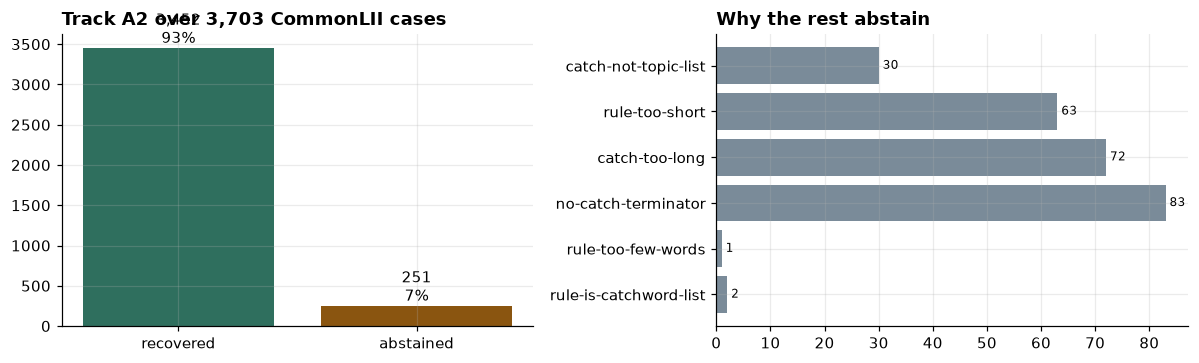

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].bar(["recovered", "abstained"], [parsed, abst], color=[PAL[0], PAL[3]])
axes[0].set_title(f"Track A2 over {n:,} CommonLII cases", loc="left", fontweight="bold")
for i, v in enumerate([parsed, abst]):
    axes[0].text(i, v, f"{v:,}\n{v/n:.0%}", ha="center", va="bottom")
rk = list(reasons.keys()); rv = list(reasons.values())
axes[1].barh(range(len(rk)), rv, color=PAL[2]); axes[1].set_yticks(range(len(rk)))
axes[1].set_yticklabels(rk); axes[1].invert_yaxis()
axes[1].set_title("Why the rest abstain", loc="left", fontweight="bold")
for i, v in enumerate(rv):
    axes[1].text(v, i, f" {v}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

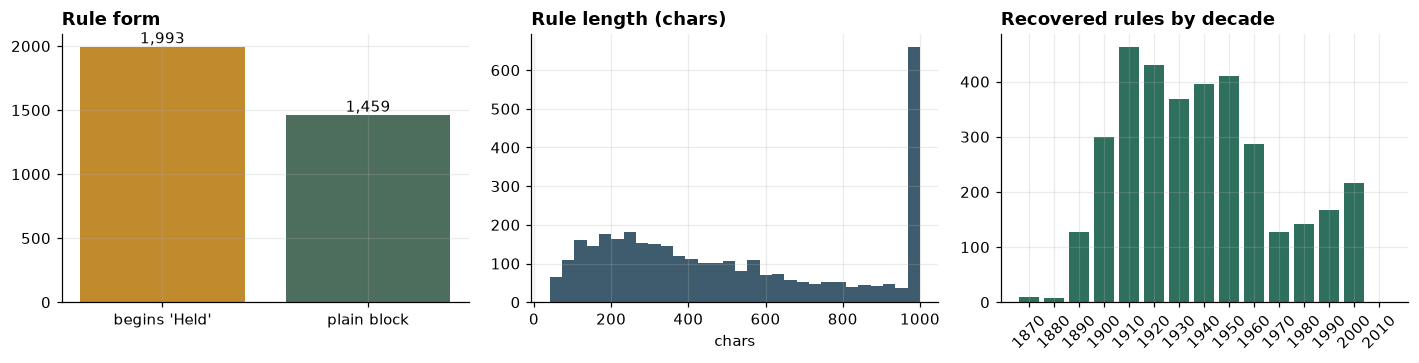

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
held = int(rules_df["begins_held"].sum()); plain = parsed - held
axes[0].bar(["begins 'Held'", "plain block"], [held, plain], color=[PAL[1], PAL[4]])
axes[0].set_title("Rule form", loc="left", fontweight="bold")
for i, v in enumerate([held, plain]):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

axes[1].hist(rules_df["rule"].str.len().clip(upper=1000), bins=30, color=PAL[6])
axes[1].set_title("Rule length (chars)", loc="left", fontweight="bold"); axes[1].set_xlabel("chars")

yr = pd.to_numeric(rules_df["year"], errors="coerce").dropna().astype(int)
dc = (yr // 10 * 10).value_counts().sort_index()
axes[2].bar(dc.index.astype(str), dc.values, color=PAL[0], width=0.8)
axes[2].set_title("Recovered rules by decade", loc="left", fontweight="bold")
axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

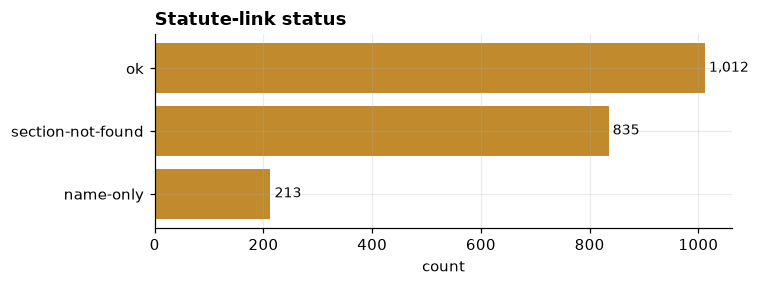

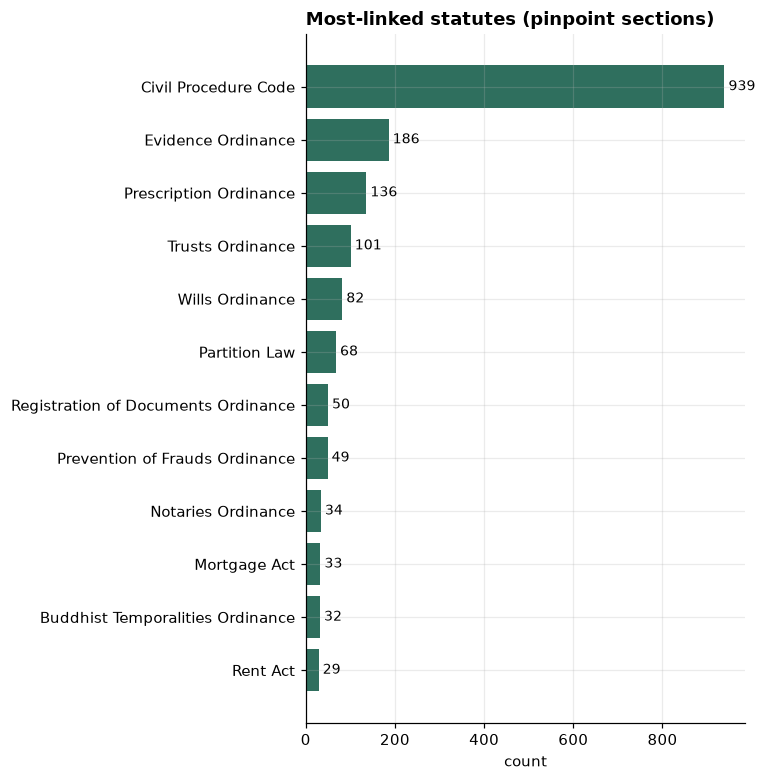

In [9]:
if not links_df.empty:
    st = links_df["status_link"].value_counts()
    barh(st.index.tolist(), st.values.tolist(), "Statute-link status", color=PAL[1])
    named = links_df.dropna(subset=["section"]).merge(
        reg_df[["source_id", "official_title"]], on="source_id", how="left")
    top = named["official_title"].value_counts().head(12)
    if len(top):
        barh([t[:42] for t in top.index], top.values.tolist(),
             "Most-linked statutes (pinpoint sections)", color=PAL[0])

## 5. Manual validation harness

Everything above is **candidate, unverified**. Below is an inline review view
(rule beside its raw source window) and an exported review sheet with blank
verdict columns for a lawyer to fill in. Change `REVIEW_N` and re-run to see more.

In [10]:
REVIEW_N = 15
random.seed(20)
review_ids = random.sample(list(rules_df["case_id"]), min(REVIEW_N, len(rules_df)))

def source_window(cid, nchars=520):
    t = re.sub(r"\s+", " ", load_text(cid))
    hs = list(HEADER.finditer(t)); t = t[hs[-1].end():] if hs else t
    navs = list(NAV.finditer(t[:600]));  t = t[navs[-1].end():] if navs else t
    return t[:nchars]

for cid in review_ids:
    row = rules_df[rules_df["case_id"] == cid].iloc[0]
    ls = links_df[links_df["case_id"] == cid]
    print("=" * 92); print(cid, "|", row["citation"])
    print("SOURCE :", source_window(cid)[:340])
    print("-> RULE:", row["rule"])
    if len(ls):
        print("-> LINK:", [(e.source_id, e.section, e.status_link) for e in ls.itertuples()])
    print()

commonlii-LKCA-1998-55 | (1999) 3 Sri LR 57
SOURCE :  57 RATNAYAKE v. DE SILVA COURT OF APPEAL. EDUSSURIYA, J., JAYASINGHE, J. C.A. NO. 15/93 (F) D.C. ANURADHAPURA NO. 14087/L. JUNE 22, 1998. JULY 21, 1998. AUGUST 24, 1998. Lease - Lease of land by North-Central Provincial Council - Validity - Should it be notarially attested? - Prevention of Frauds Ordinance S. 2, 17 - Provincial Councils 
-> RULE: Held: 1. Document (P1) does not purport to be made by or under the hand of the President as required by section 1 (3) of the Appendix II of the Constitution and therefore, is not a valid conveyance.
-> LINK: [('SRC001', '2', 'section-not-found')]

commonlii-LKCA-1984-38 | (1985) 2 Sri LR 25
SOURCE :  25 MUSTAPHA ASMA UMMA v. RAJAPAKSA COURT OF APPEAL. H. A. G. DE SILVA, J. AND G. P. S. DE SILVA, J. C.A. 40/75 (Inty.) - D.C. GAMPAHA 15202/P: AUGUST 29 AND 30, 1984. Partition suit - Claim of prescriptive title to specific lot by recipients of undivided shares from co-owner who is alleged to h

In [11]:
rules_df.to_csv(OUT / "rules_recovered.csv", index=False)
links_df.to_csv(OUT / "statute_links.csv", index=False)

review = rules_df.sample(min(60, len(rules_df)), random_state=20).copy()
review["statute_links"] = review["case_id"].map(
    lambda c: "; ".join(f"{e.source_id}:{e.section}" for e in links_df[links_df.case_id == c].itertuples() if e.section))
for col in ["rule_correct(y/n)", "rule_is_ratio(y/n)", "statute_link_correct(y/n)", "notes"]:
    review[col] = ""
review = review[["case_id", "citation", "catchwords", "rule", "statute_links",
                 "rule_correct(y/n)", "rule_is_ratio(y/n)", "statute_link_correct(y/n)", "notes"]]
review.to_csv(OUT / "review-sample.csv", index=False)
print("wrote:", OUT / "rules_recovered.csv")
print("      ", OUT / "statute_links.csv")
print("      ", OUT / "review-sample.csv", f"({len(review)} rows for lawyer sign-off)")

wrote: d:\projects\Draftly-Project\draftly-research\evaluation\runs\headnote-recovery-v1\rules_recovered.csv
       d:\projects\Draftly-Project\draftly-research\evaluation\runs\headnote-recovery-v1\statute_links.csv
       d:\projects\Draftly-Project\draftly-research\evaluation\runs\headnote-recovery-v1\review-sample.csv (60 rows for lawyer sign-off)


## 6. Takeaways

- Track A2 recovers a verbatim rule from **93.2%** of the 3,703 CommonLII
  judgments (3,452 cases; up from 3,258/88.0% at the start of hardening, and
  from 524 via the original `Held:`-only extractor), with no LLM spend and no
  dependence on the missing LawNet headnotes.
- **The single largest fix, by far: the rule-content catchword-list guard was
  false-firing on ordinary English, not on catchword lists.** The guard
  rejects a candidate rule if it contains 4+ dash-pattern matches, on the
  theory that dash-heavy text is still a topic list. But the dash pattern
  didn't require any space around the dash, so it matched ordinary no-space
  hyphenated compounds just as readily as a real spaced-out topic list:
  `co-owner(s)`, `judgment-debtor`, `judgment-creditor`, `Plaintiff-Appellant`,
  `Defendant-Respondent`, `Roman-Dutch`, `Attorney-General`. A rule paragraph
  that mentions "co-owner" four times (extremely common in partition/property
  cases — Draftly's own conveyancing domain) tripped the exact same threshold
  as an actual catchword dump. Sampling all 182 cases in this bucket found
  175/182 had **no** judge-attribution dash and were dominated by these
  compounds (`co-owner` alone accounted for 155 of the 182). Fix: require a
  space on at least one side of the dash for this guard specifically —
  matching how genuine catchword lists are actually typeset in this corpus
  (`"Lease - Assignment - Breach"`, always spaced). Catchword-*boundary*
  detection (`DASH_CATCH`, used elsewhere) was left untouched.
  - Result: 180/182 cases (99%) now pass. The 2 that still correctly fail are
    the guard doing its real job — one still has counsel names bled into the
    rule window, the other genuinely is an un-boundaried catchword dump.
  - Verified zero regression: every other abstention bucket's count is
    byte-for-byte identical before and after this change.
  - Precision-audited 25 of the 180 newly-recovered cases: large majority
    clean genuine rules (including the exact `judgment-creditor`/
    `judgment-debtor`/`co-owner` cases the fix targeted). The rest were
    already-known issue classes (see below) plus one **new, honestly-flagged
    observation**: 2/25 sampled cases show leftover catchword-style dash
    fragments bleeding into the rule text — a pre-existing catchword-*boundary*
    miss in `find_catch_end` that used to be masked by coincidentally tripping
    the old over-broad guard, and is now visible instead of hidden. Content
    stays verbatim and `status=unverified` either way, so this is a
    completeness issue for lawyer review, not a fabrication risk — but it's a
    real, not-yet-fixed defect, flagged here rather than swept under the +180.
- Earlier structural fixes in this pass (all still in effect):
  1. **Corrupted dash recovery.** 899 of the 3,703 harvested `.txt` files have
     lost their original em-dash byte during the CommonLII harvest/encoding
     step, leaving the Unicode replacement character (`�`) in its place.
     A separate, broadened dash pattern (`DASH_CATCH`, catchword-boundary
     detection only) treats `�` and doubled hyphens (`--`) as valid topic
     separators.
  2. **Quote-abutting terminators.** Catchword lists ending `..." Judge, J.`
     (closing quote directly against the period, no space) were rejected by
     the terminator regex, which required whitespace immediately after the
     period. Fixed to allow an optional immediate quote first.
  3. **Fact-narrative bleed.** The `BODY` stop-marker recognised `"THE facts"`
     but not the equally common `"THIS action/appeal/suit/case was..."`
     construction, so 7 cases were pulling 150-600 characters of case facts
     into the "rule" before stopping. Extended `BODY` to catch both forms. A
     related variant, `"THIS was an action..."` (noun after "was" rather than
     before), was seen once in later auditing and is not yet covered.
  - Two follow-on attempts were tested and reverted as net-negative even after
    adding guards: allowing a bare `.` before a dash to catch
    `"et seq.-Topic"` (broke on `"v.�"` in case captions); excluding only
    `v.`/`vs.` from that with a lookbehind (fixed the target case but still
    cost more elsewhere than it gained). Recall was not allowed to win over
    precision in either case.
- **Known, documented limitations (not fixed this pass):**
  1. The `HELD` marker match is not anchored to sentence-start, so ordinary
     prose uses of "held" as a verb (*"...who held a power of attorney..."*,
     *"...land held by them in common..."*, *"...at the sale held by the
     Fiscal..."*) can occasionally be mistaken for the editorial "Held,"
     marker. Confirmed present in the original, unhardened parser too (not
     introduced this pass). An estimated ~6-8% of recovered cases per random
     precision audits. Four candidate heuristics (match position, trailing
     punctuation, capitalisation, "that" within N characters) were tested and
     rejected with evidence — none reliably separates genuine markers (used
     lowercase and unpunctuated across different NLR eras) from ordinary verb
     usage. Needs a small labelled set to calibrate against, not another
     regex guess.
  2. Catchword-boundary misses that leave stray dash-fragments in the rule
     text (see the spaced-dash section above) — newly visible, not newly
     created, and not yet quantified beyond the 2/25 sample.
  - Everything downstream of `status=unverified` exists precisely to catch
    both classes of error before they reach a lawyer-facing answer.
- It remains **precision-first**: 6.8% abstain (jumbled OCR, no dash-list
  headnote, atypical layout, single-topic catchwords with no dash at all) and
  flow to the bounded LLM track rather than emit a non-rule. The hard guard
  rejecting any candidate that is itself a catchword list was kept intact
  throughout — narrowed to fire correctly rather than removed — and
  re-verified against the full corpus after every change.
- Statute links are taken straight from the headnote (the editor's own
  statement of the governing provision) and validated against the section
  index where the statute is in the catalogue; out-of-catalogue citations keep
  a name/verbatim reference.
- **Everything is `status=unverified`.** These are yield and precision-audit
  numbers, not legal-correctness scores; lawyer review of `review-sample.csv`
  (statute attribution especially, and the two known-limitation classes
  flagged above) is required before any rule or link is treated as authority.
